In [ ]:
import matplotlib.pyplot as plt
from matplotlib  import rcParams
import xarray as xr

import pandas as pd
rcParams.update({'figure.autolayout': True})
rcParams['font.size'] = 14
rcParams['font.family'] = 'arial narrow'
plt.style.use('ggplot')

(array([1.1324e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 6.0000e+00]),
 array([-7.38288468e-01,  5.46807426e+28,  1.09361485e+29,  1.64042228e+29,
         2.18722970e+29,  2.73403713e+29,  3.28084456e+29,  3.82765198e+29,
         4.37445941e+29,  4.92126683e+29,  5.46807426e+29,  6.01488169e+29,
         6.56168911e+29,  7.10849654e+29,  7.65530396e+29,  8.20211139e+29,
         8.74891882e+29,  9.29572624e+29,  9.84253367e+29,  1.03893411e+30,
         1.09361485e+30]),
 <BarContainer object of 20 artists>)

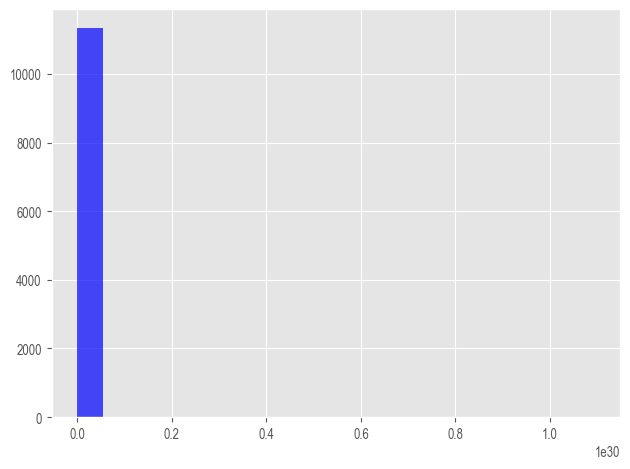

In [56]:
df = pd.read_csv('soft_x_rays.csv')

hcaml = df.loc[df.variable_name == 'horizontal_cam_upper']
means =  hcaml.loc[hcaml.checker_name == 'Mean', 'value'].astype(float)

plt.hist(means, bins=20, alpha=0.7, label='Max', color='blue')

In [57]:
labels = means > means.mean() + 12 * means.std()
outliers = df.loc[means.loc[labels].index]
inliers = df.loc[means.loc[~labels].index]

/home/ir-jack5/rds/rds-ukaea-ap002-mOlK9qn0PlQ/fairmast/upload-tmp/level2/19454.zarr


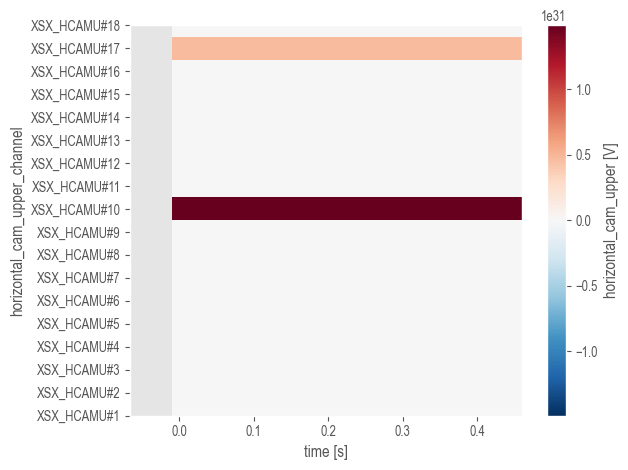

In [58]:
print(outliers.file_path.iloc[2])

ds = xr.open_zarr('https://s3.echo.stfc.ac.uk/mast/level2/shots/19454.zarr', group='soft_x_rays')
tcam = ds['horizontal_cam_upper']
tcam.plot(x='time')

/home/ir-jack5/rds/rds-ukaea-ap002-mOlK9qn0PlQ/fairmast/upload-tmp/level2/11768.zarr


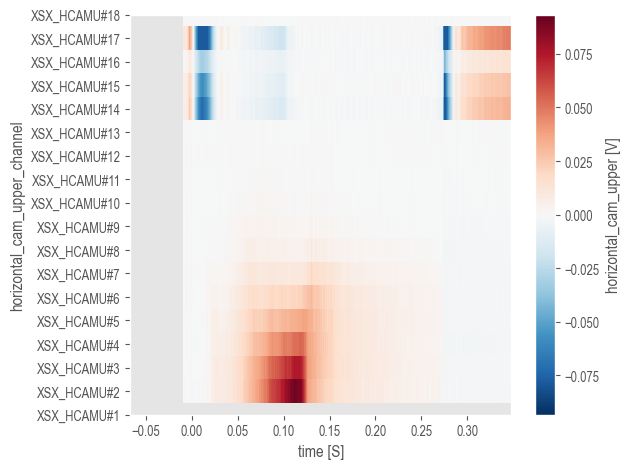

In [59]:
print(inliers.file_path.iloc[0])
ds = xr.open_zarr('https://s3.echo.stfc.ac.uk/mast/level2/shots/11768.zarr', group='soft_x_rays')
tcam = ds['horizontal_cam_upper']
tcam.plot(x='time')